# Correcting plate position: hit-calling versus profiling

Position effects -- edge evaporation, thermal corners, dispensing drift -- are real, and
`mt.pp.correct_plate_position` removes a plate's row and column effects with a two-way median polish (Tukey;
a few extreme wells cannot distort it). Whether you *should* correct depends on what you measure: a single
readout (one number per well, as in a biochemical hit screen) or a whole multivariate profile (hundreds of
morphology features per well).

The default, `method="b_score"` ({cite:t}`Brideau_2003`), divides the median-polish residual by the plate's
median absolute deviation (MAD), giving a robust position-corrected z-score per plate; `method="median_polish"`
subtracts the effects and keeps the data's units. This page runs both on data: a synthetic single-readout plate
where the correction recovers hidden hits, and real JUMP-Target-2 profiles where it lowers compound retrieval.
Position correction is for hit-calling against a gradient, not for multivariate profiling.

In [1]:
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt
from mantispy._core.plate import PLATE_FORMATS, well_col, well_name, well_row
from mantispy._core.schema import stamp

warnings.filterwarnings("ignore")

## Hit-calling: the correction recovers hidden hits

On a single readout a gradient can bury real hits -- an active well in a cool corner reads lower than an
inactive one in a warm corner. The plate below is synthetic: a strong row and column gradient, six real hits
placed at random, and otherwise-inactive wells. We score the result by how many of the six hits land in the top
six wells (precision at six).

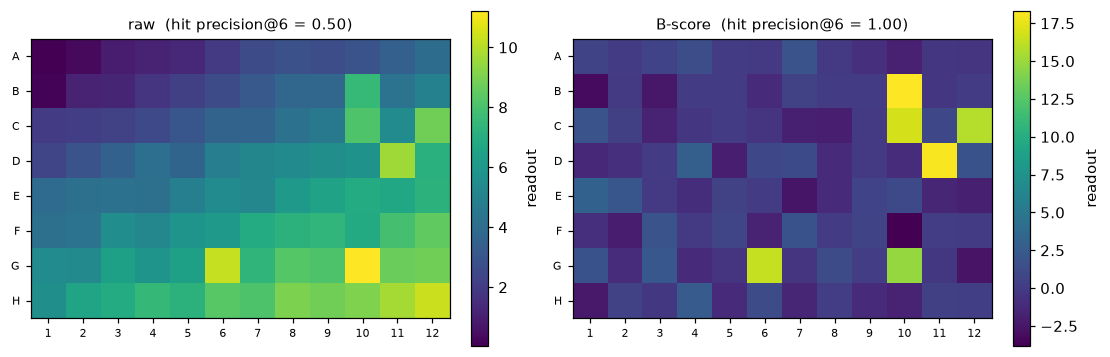

In [2]:
n_rows, n_cols = PLATE_FORMATS[96]
names = [well_name(r, c) for r in range(n_rows) for c in range(n_cols)]
rows = np.array([well_row(w) for w in names], dtype=float)
cols = np.array([well_col(w) for w in names], dtype=float)
rng = np.random.default_rng(0)

gradient = 6.0 * rows / rows.max() + 4.0 * cols / cols.max()
readout = gradient + rng.normal(0.0, 0.3, len(names))
hits = rng.choice(len(names), size=6, replace=False)  # six real hits, scattered at random
readout[hits] += 3.0  # a randomized layout, as B-score assumes

plate = ad.AnnData(
    X=readout.reshape(-1, 1).astype(np.float32),
    obs=pd.DataFrame(
        {"Metadata_Plate": "demo", "Metadata_Well": names, "Metadata_Control": True},
        index=[str(i) for i in range(len(names))],
    ),
    var=pd.DataFrame(index=["readout"]),
)
stamp(plate, resolution="well")
scored = mt.pp.correct_plate_position(plate, method="b_score", copy=True)


def hit_precision(values, k=6):
    """Share of the true hits among the top-k wells -- how we measure whether correction helped."""
    return len(set(np.argsort(values)[::-1][:k]) & set(hits.tolist())) / k


raw_precision = hit_precision(readout)
b_precision = hit_precision(np.asarray(scored.X, dtype=float)[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), layout="constrained")
mt.pl.plate(plate, color="readout", plate="demo", ax=axes[0])
axes[0].set_title(f"raw  (hit precision@6 = {raw_precision:.2f})", fontsize=10)
mt.pl.plate(scored, color="readout", plate="demo", ax=axes[1])
axes[1].set_title(f"B-score  (hit precision@6 = {b_precision:.2f})", fontsize=10)
plt.show()

Raw, the gradient lifts warm-corner background above hits in cool wells, so some hits miss the top six; after
the B-score the gradient is gone and the six hits are the top six (precision in the panel titles). The B-score
works here because four things hold: a single readout, hit-calling, a randomized layout, and mostly-inactive
wells. The rest of this page is a profile, where they do not.

## Profiling: the same correction removes signal

A morphological profile is different: hundreds of correlated features per well, where position is a small part
and the biology is each compound's full multivariate shift, which has to stay comparable across plates and
laboratories. Below are five plates from one laboratory (source_4) that carry a real position artifact and five
from other laboratories that do not, each normalized per plate against its DMSO negative controls (`negcon`)
with `mad_robustize` (median-centre, MAD-scale). `detect_plate_position` scores each plate by cross-validation:
it fits the row and column effects on part of the control wells and checks how well they predict the held-out
controls (`cv_r2_median`), with `frac_features_positive` the share of features where that prediction beats the
plate mean. A score above zero means the pattern generalizes.

In [3]:
flagged = ["BR00126113", "BR00126114", "BR00126115", "BR00126116", "BR00126117"]
clean = ["JCPQC051", "ACPJUM012", "1053600674", "GR00003394", "CP1-SC1-25"]
jump = mt.ds.jump_target2(plates=flagged + clean)
mt.pp.normalize(jump, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(jump, na_cutoff=0.0)
jump = mt.pp.subset_features(jump)

mt.pp.detect_plate_position(jump, reference="negcon")
detection = jump.uns["mantispy"]["plate_position_detection"].copy()
source = jump.obs.drop_duplicates("Metadata_Plate").set_index(
    jump.obs.drop_duplicates("Metadata_Plate")["Metadata_Plate"].astype(str)
)["Metadata_Source"]
detection["source"] = detection["plate"].map(source.to_dict())
detection.sort_values("cv_r2_median", ascending=False).round({"cv_r2_median": 3, "frac_features_positive": 3})

,plate,n_controls,cv_r2_median,frac_features_positive,reason,source
2,BR00126113,64,0.784,0.823,,source_4
5,BR00126116,64,0.754,0.789,,source_4
4,BR00126115,64,0.712,0.795,,source_4
6,BR00126117,64,0.710,0.793,,source_4
3,BR00126114,64,0.504,0.651,,source_4
8,GR00003394,256,-0.129,0.307,,source_9
7,CP1-SC1-25,64,-0.545,0.153,,source_7
9,JCPQC051,64,-0.659,0.169,,source_3
1,ACPJUM012,64,-0.825,0.026,,source_5
0,1053600674,65,-0.839,0.084,,source_2


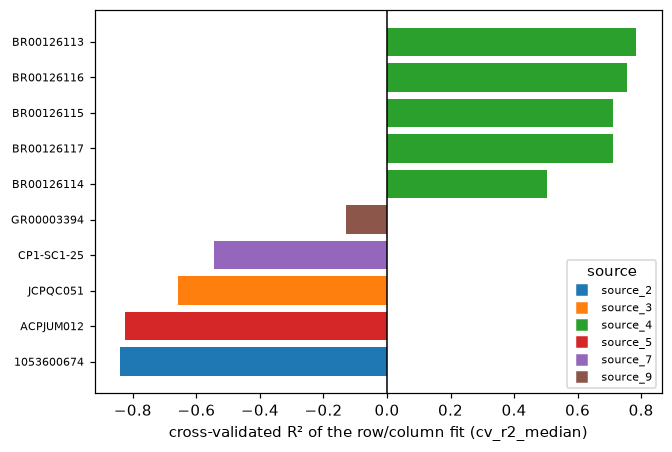

In [4]:
scored = detection.dropna(subset=["cv_r2_median"]).sort_values("cv_r2_median")
palette = dict(zip(sorted(scored["source"].unique()), plt.cm.tab10.colors, strict=False))

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
ax.barh(range(len(scored)), scored["cv_r2_median"], color=[palette[s] for s in scored["source"]])
ax.axvline(0.0, color="black", lw=1)
ax.set_yticks(range(len(scored)), scored["plate"], fontsize=7)
ax.set_xlabel("cross-validated R² of the row/column fit (cv_r2_median)")
ax.legend(
    handles=[plt.Line2D([], [], marker="s", ls="", color=c, label=s) for s, c in palette.items()],
    fontsize=7,
    loc="lower right",
    title="source",
)
plt.show()

The five source_4 plates score well above zero and the others below it: the artifact is real and specific to one
laboratory. Two things follow from a positive score. It means the row and column pattern is stable across
control wells -- not that correcting it will help the biology, which the retrieval test below settles. And it is
a quality-control signal: on a profiling screen, excluding or inspecting such a plate is usually better than
correcting it. In a scan of the full 141-plate Target-2 set only six plates scored positive, five of them this
one laboratory, so correcting every plate would alter them all to address a few.

The scores summarize the plates; here is the structure itself. We average the most position-correlated
features into one signal and show the control wells only -- on treated wells the compound moves the signal and
hides the field. The flagged plate has coherent spatial structure, a clean plate from another laboratory has
scattered noise, and median polish flattens it:

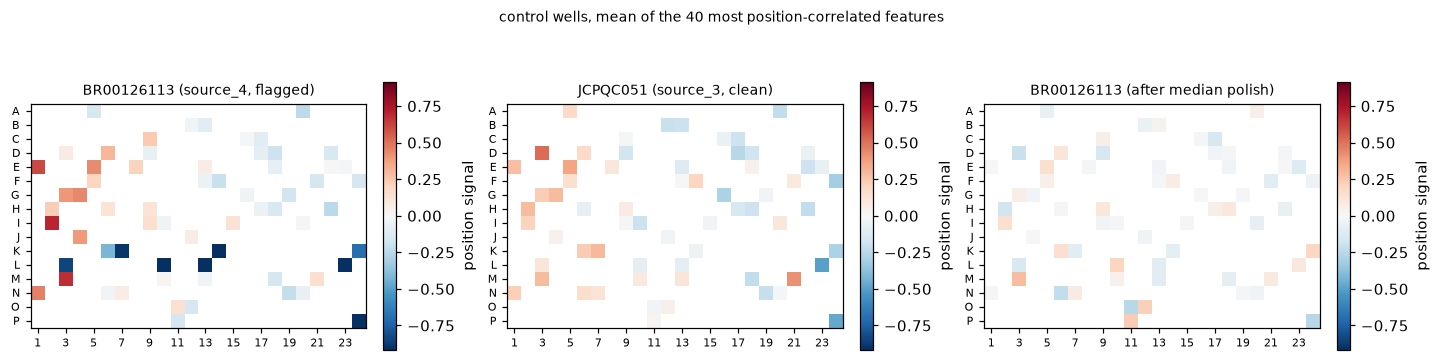

In [5]:
flagged_plate, clean_plate = "BR00126113", "JCPQC051"
controls = jump[(jump.obs["Metadata_Plate"].astype(str) == flagged_plate) & jump.obs["Metadata_Control"].to_numpy()]
cv = np.asarray(controls.X, dtype=float)
crows = np.array([well_row(w) for w in controls.obs["Metadata_Well"]], dtype=float)
ccols = np.array([well_col(w) for w in controls.obs["Metadata_Well"]], dtype=float)


def position_score(column):
    row_r = np.corrcoef(crows, column)[0, 1] if np.ptp(column) > 0 else 0.0
    col_r = np.corrcoef(ccols, column)[0, 1] if np.ptp(column) > 0 else 0.0
    return abs(np.nan_to_num(row_r)) + abs(np.nan_to_num(col_r))


# average the 40 most position-correlated features into one signal, so single-feature outliers do not dominate
top = np.argsort([position_score(cv[:, j]) for j in range(cv.shape[1])])[::-1][:40]


def signal(adata):
    return np.asarray(adata.X, dtype=np.float64)[:, top].mean(axis=1)


jump.obs["position signal"] = signal(jump)
corrected = mt.pp.correct_plate_position(
    jump, method="median_polish", reference="negcon", plates=[flagged_plate], copy=True
)
corrected.obs["position signal"] = signal(corrected)


# show the control wells only: on treated wells the compound itself moves the signal, which hides the position field
def controls_of(adata, plate):
    return adata[(adata.obs["Metadata_Plate"].astype(str) == plate) & adata.obs["Metadata_Control"].to_numpy()]


limit = float(np.nanpercentile(np.abs(controls_of(jump, flagged_plate).obs["position signal"]), 95))
style = {"color": "position signal", "cmap": "RdBu_r", "vmin": -limit, "vmax": limit}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained")
mt.pl.plate(controls_of(jump, flagged_plate), plate=flagged_plate, ax=axes[0], **style)
mt.pl.plate(controls_of(jump, clean_plate), plate=clean_plate, ax=axes[1], **style)
mt.pl.plate(controls_of(corrected, flagged_plate), plate=flagged_plate, ax=axes[2], **style)
axes[0].set_title(f"{flagged_plate} (source_4, flagged)", fontsize=9)
axes[1].set_title(f"{clean_plate} (source_3, clean)", fontsize=9)
axes[2].set_title(f"{flagged_plate} (after median polish)", fontsize=9)
fig.suptitle("control wells, mean of the 40 most position-correlated features", fontsize=9)
plt.show()

Median polish removes the gradient, as the last panel shows. Whether that helps depends on the readout. For
compounds, measure cross-source retrieval -- whether a compound run at different laboratories is found again --
as mean average precision (mAP) against a shuffled null, counting how many compounds clear it. Retrieval before
and after correcting only the flagged plates:

In [6]:
def cross_source_map(adata):
    """Mean cross-source compound mAP, and how many compounds clear the corrected null."""
    treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
    mt.tl.map(
        treated,
        pos_sameby=["Metadata_Perturbation"],
        pos_diffby=["Metadata_Source"],
        neg_diffby=["Metadata_Perturbation"],
        null_size=500,
        seed=0,
    )
    scores = treated.uns["mantispy"]["map"]
    return round(float(scores["mean_average_precision"].mean()), 3), int(scores["below_corrected_p"].sum())


passing = list(detection.loc[detection["cv_r2_median"] > 0, "plate"])
n_treated = int(jump.obs.loc[~jump.obs["Metadata_Control"].to_numpy(), "Metadata_Perturbation"].nunique())

ladder = {"normalize only": cross_source_map(jump)}
for method in ("median_polish", "b_score"):
    corrected = jump.copy()
    mt.pp.correct_plate_position(corrected, method=method, reference="negcon", plates=passing)
    ladder[f"+ {method} (only the flagged plates)"] = cross_source_map(corrected)

pd.DataFrame(
    [
        {"pipeline": name, "cross-source mAP": value, f"significant of {n_treated}": hits}
        for name, (value, hits) in ladder.items()
    ]
)

,pipeline,cross-source mAP,significant of 301
0,normalize only,0.016,38
1,+ median_polish (only the flagged plates),0.015,25
2,+ b_score (only the flagged plates),0.014,21


Correction lowers retrieval. The mAP changes are small (0.016 to 0.014 at this seed), but the number of
compounds clearing the null falls from 38 to 21. The correction did what it promises -- the gradient is gone --
but it is a bad trade on a profile. The row and column fit comes from only a few dozen control wells, so
subtracting it adds noise to every treated well; and the B-score rescales each plate by its own MAD on top of
the normalization already applied, so a compound is transformed differently on each plate. Cross-source
retrieval needs the opposite. For profiling, normalize per plate, run `pp.harmony` on the batch, and use
`detect_plate_position` to flag the rare plate worth excluding rather than correcting.

## Which to use

| situation | method |
| --- | --- |
| hit-calling a single readout against a gradient, randomized layout | `correct_plate_position(method="b_score")` |
| removing a gradient while keeping the data's units | `correct_plate_position(method="median_polish")` |
| building multivariate profiles | do not position-correct; normalize per plate and run `pp.harmony` on the batch |
| a plate scoring `cv_r2_median > 0` on a profiling screen | treat it as QC: exclude or inspect it |

For a profiling pipeline:

```python
import scanpy as sc

mt.pp.normalize(adata, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.detect_plate_position(adata, reference="negcon")
flagged = adata.uns["mantispy"]["plate_position_detection"].query("cv_r2_median > 0")["plate"]
adata = adata[~adata.obs["Metadata_Plate"].isin(flagged)].copy()
sc.pp.pca(adata, n_comps=50)
mt.pp.harmony(adata, batch_key="Metadata_Batch")
```

Caveats:

- Nonrandom layouts. Both methods assume position is independent of treatment. Controls down whole columns, or a
  dose gradient across columns, is the position signal, and correcting it removes the design
  ({cite:t}`Brideau_2003`; median polish fits a column effect only where control wells sit).
- High hit rates. Median polish and the MAD assume most wells are inactive; many active wells bias the robust
  centre and the B-score compresses real signal.
- The B-score also normalizes. It rescales each plate by its MAD, so run it instead of a separate per-plate
  normalization, or use `median_polish` to keep your own.
- Learned correctors are a different case. For genetic perturbations with deep features, methods like cpDistiller
  correct well position where this linear correction does not.

Correct a single readout against a gradient; do not correct a whole profile. The within-plate mechanics are in
{doc}`the artifacts tutorial </tutorials/profiles/artifacts>`.